#
### Assignment II, Group 9: Object Detection Project

**Objectives:**
- Train a YOLOv8 model on a vehicle detection dataset from Roboflow
- Perform data augmentation experiments
- Analyze performance on small vs large objects
- Critically evaluate results



In [1]:
# required libraries
!pip install ultralytics roboflow matplotlib seaborn pandas numpy Pillow tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 65.8 MB/s eta 0:00:00


In [2]:
import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO


sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Dataset from Roboflow
 [https://universe.roboflow.com](https://universe.roboflow.com/skripsi-1qzlz/vehicle-detection-bvxpr)


In [3]:
# !pip install roboflow -q

from roboflow import Roboflow


rf = Roboflow(api_key="EdHj8xY6Vde9KBMpwFjy")
project = rf.workspace("skripsi-1qzlz").project("vehicle-detection-bvxpr")
version = project.version(1)
dataset = version.download("yolov8")


dataset_path = Path(dataset.location)
data_yaml    = str(dataset_path/'data.yaml')
print(f'Dataset ready at: {dataset_path}')
print(f'data.yaml: {data_yaml}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vehicle-Detection-1 in yolov8:: 100%|██████████| 2012/2012 [00:00<00:00, 2470.39it/s]

Dataset ready at: /content/Vehicle-Detection-1
data.yaml: /content/Vehicle-Detection-1/data.yaml


##Dataset Exploration

In [4]:
import yaml

with open(data_yaml, 'r') as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg['names']
num_classes = data_cfg['nc']

print(f'Classes ({num_classes}): {class_names}')
print(f'Train : {dataset_path}/train')
print(f'Valid : {dataset_path}/valid')
print(f'Test  : {dataset_path}/test')

for split in ['train', 'valid', 'test']:
    img_dir = dataset_path / split / 'images'
    if img_dir.exists():
        n = len(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')))
        print(f' {split}: {n} images')

Classes (4): ['bus', 'car', 'motorbike', 'truck']
Train : /content/Vehicle-Detection-1/train
Valid : /content/Vehicle-Detection-1/valid
Test  : /content/Vehicle-Detection-1/test
 train: 800 images
 valid: 100 images
 test: 100 images


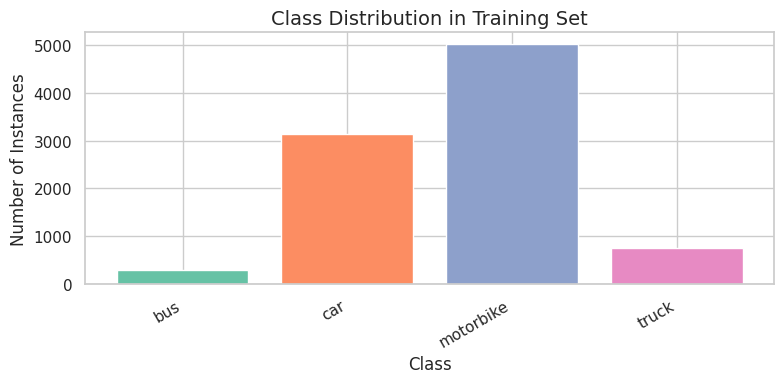

{'bus': 295, 'car': 3137, 'motorbike': 5007, 'truck': 755}


In [5]:
def count_class_distribution(split='train'):

    label_dir = dataset_path / split / 'labels'
    counts = {name: 0 for name in class_names}

    for lbl_file in label_dir.glob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                cls_id = int(line.strip().split()[0])
                if cls_id < len(class_names):
                    counts[class_names[cls_id]] += 1
    return counts

train_counts = count_class_distribution('train')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(train_counts.keys(), train_counts.values(), color=sns.color_palette('Set2'))
ax.set_title('Class Distribution in Training Set', fontsize=14)
ax.set_xlabel('Class')
ax.set_ylabel('Number of Instances')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()
print(train_counts)

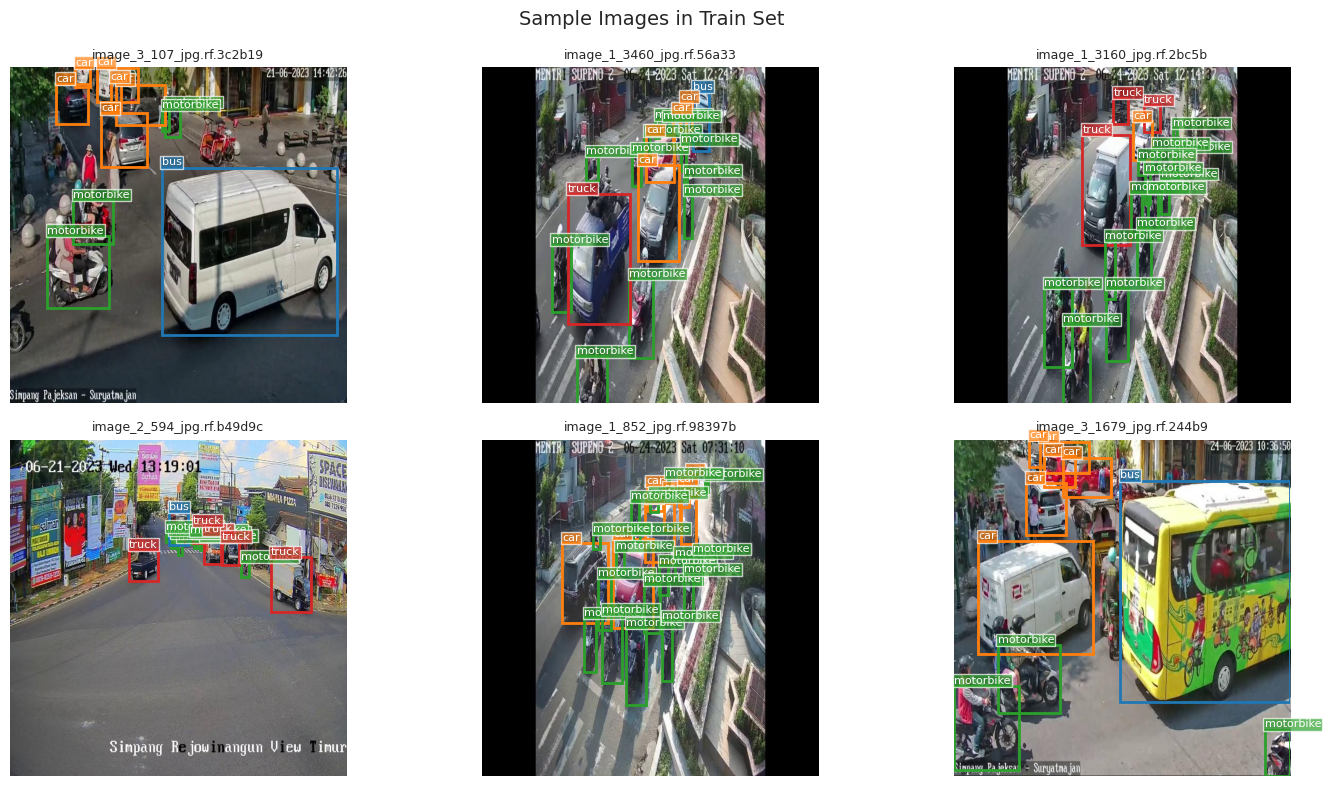

In [6]:
import matplotlib.patches as patches
def visualize_samples(split='train', n=6):


    img_dir  = dataset_path / split / 'images'
    lbl_dir  = dataset_path / split / 'labels'
    imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    imgs = np.random.choice(imgs, min(n, len(imgs)), replace=False)

    colors = plt.colormaps.get_cmap('tab10')
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, img_path in zip(axes, imgs):
        img = Image.open(img_path).convert('RGB')
        W, H = img.size
        ax.imshow(img)

        lbl_path = lbl_dir / (Path(img_path).stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = list(map(float, line.strip().split()))
                    cls_id = int(parts[0])

                    cx, cy, bw, bh = parts[1], parts[2], parts[3], parts[4]
                    x1 = (cx - bw/2) * W
                    y1 = (cy - bh/2) * H

                    rect = patches.Rectangle( (x1, y1), bw*W, bh*H, linewidth=2, edgecolor=colors(cls_id), facecolor='none')

                    ax.add_patch(rect)

                    ax.text(x1, y1 - 4, class_names[cls_id], color='white', fontsize=8, bbox=dict(facecolor=colors(cls_id), alpha=0.7, pad=1))

        ax.axis('off')
        ax.set_title(Path(img_path).name[:25], fontsize=9)

    plt.suptitle(f'Sample Images in {split.capitalize()} Set', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'samples_{split}.png')
    plt.show()

visualize_samples('train')

## Baseline Training (No Augmentation)

We train **YOLOv8n** with augmentation disabled to get a clean baseline.

In [7]:
# Experiment 1: No Augmentation
import time
start = time.time()

EPOCHS    = 30
IMG_SIZE  = 640
BATCH     = 16
MODEL     = 'yolov8n.pt'

model_baseline = YOLO(MODEL)

results_baseline = model_baseline.train(
    data      = data_yaml,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    name      = 'run_baseline',
    project   = 'vehicle_detection',


    hsv_h     = 0.0,
    hsv_s     = 0.0,
    hsv_v     = 0.0,
    degrees   = 0.0,
    translate = 0.0,
    scale     = 0.0,
    shear     = 0.0,
    flipud    = 0.0,
    fliplr    = 0.0,
    mosaic    = 0.0,
    mixup     = 0.0,
    verbose   = True
)

end = time.time()

print("Time  :", end - start, "seconds")


Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Vehicle-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=run_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

## Augmentation Experiments

We train two more variants:
- **Default augmentation** (YOLOv8 defaults)
- **Heavy augmentation** (aggressive mosaic, color, blur)

In [8]:
# Experiment 2: Default Augmentation

import time
start = time.time()

model_default = YOLO(MODEL)

results_default = model_default.train(
    data    = data_yaml,
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH,
    name    = 'run_default_aug',
    project = 'vehicle_detection',

    # YOLOv8 default augmentation settings
    hsv_h   = 0.015,
    hsv_s   = 0.7,
    hsv_v   = 0.4,
    fliplr  = 0.5,
    mosaic  = 1.0,
    verbose = True
)

end = time.time()

print("Time  :", end - start, "seconds")


Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Vehicle-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run_default_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# Experiment 3: Heavy Augmentation

import time
start = time.time()

model_heavy = YOLO(MODEL)

results_heavy = model_heavy.train(
    data      = data_yaml,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    name      = 'run_heavy_aug',
    project   = 'vehicle_detection',

    # Aggressive augmentation
    hsv_h     = 0.05,
    hsv_s     = 0.9,
    hsv_v     = 0.6,

    degrees   = 15.0,
    translate = 0.2,
    scale     = 0.6,
    shear     = 5.0,

    flipud    = 0.2,
    fliplr    = 0.5,

    mosaic    = 1.0,
    mixup     = 0.15,

    verbose   = True
)

end = time.time()

print("Time  :", end - start, "seconds")


Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Vehicle-Detection-1/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.05, hsv_s=0.9, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run_heavy_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

## Compare Augmentation Results

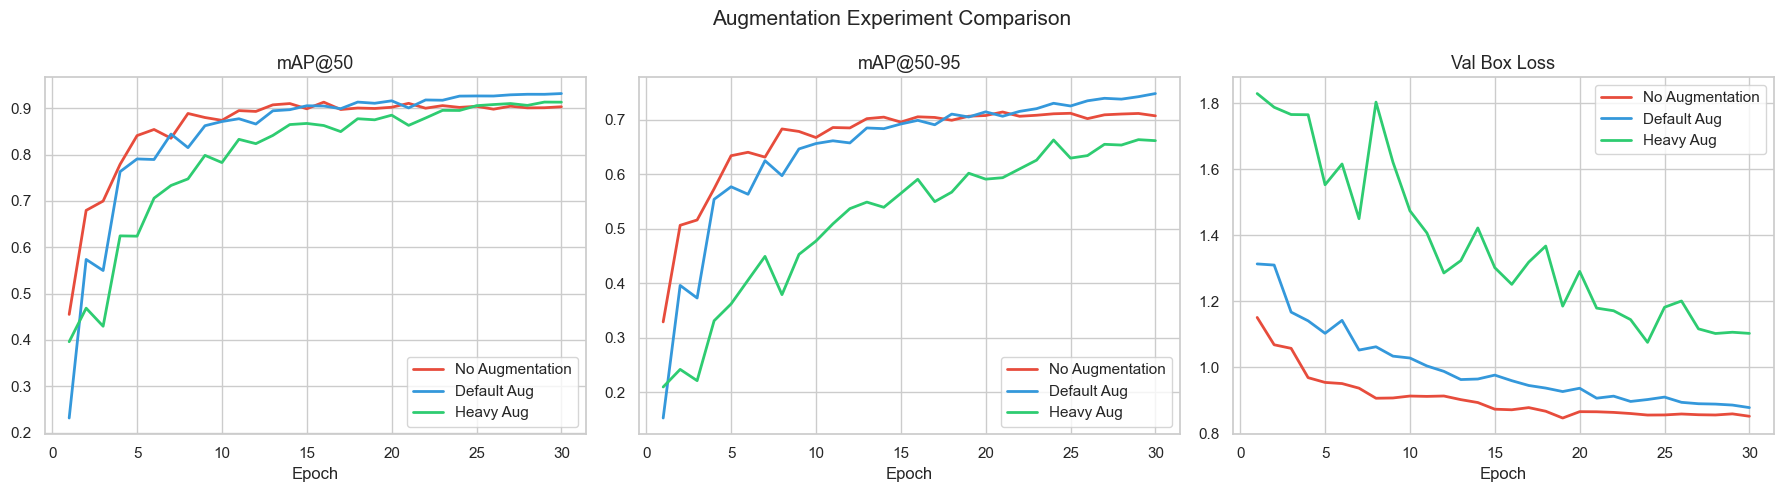

In [11]:
def load_results_csv(run_name):

    path = Path('/content/runs/detect/vehicle_detection') / run_name / 'results.csv'
    if not path.exists():
        raise FileNotFoundError(f'results.csv not found at {path}. Did training complete?')

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    if 'epoch' not in df.columns:
        df.insert(0, 'epoch', range(len(df)))
    return df

df_base    = load_results_csv('run_baseline')
df_default = load_results_csv('run_default_aug')
df_heavy   = load_results_csv('run_heavy_aug')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('metrics/mAP50(B)',    'mAP@50'),
    ('metrics/mAP50-95(B)', 'mAP@50-95'),
    ('val/box_loss',        'Val Box Loss')
]

labels  = ['No Augmentation', 'Default Aug', 'Heavy Aug']
dframes = [df_base, df_default, df_heavy]
colors  = ['#e74c3c', '#3498db', '#2ecc71']

for ax, (col, title) in zip(axes, metrics):
    for df, label, color in zip(dframes, labels, colors):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=label, color=color, linewidth=2)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('Augmentation Experiment Comparison', fontsize=15)
plt.tight_layout()
plt.savefig('augmentation_comparison.png')
plt.show()

In [12]:
# Summary table
def best_metrics(df, label):
    def safe_max(df, col):
        return round(df[col].max(), 4) if col in df.columns else float('nan')
    return {
        'Experiment'    : label,
        'Best mAP@50'   : safe_max(df, 'metrics/mAP50(B)'),
        'Best mAP@50-95': safe_max(df, 'metrics/mAP50-95(B)'),
        'Best Precision': safe_max(df, 'metrics/precision(B)'),
        'Best Recall'   : safe_max(df, 'metrics/recall(B)'),
    }

summary = pd.DataFrame([
    best_metrics(df_base,    'No Augmentation'),
    best_metrics(df_default, 'Default Aug'),
    best_metrics(df_heavy,   'Heavy Aug'),
])

print('\n Augmentation Experiment Summary:')
display(summary)


 Augmentation Experiment Summary:


,Experiment,Best mAP@50,Best mAP@50-95,Best Precision,Best Recall
0,No Augmentation,0.9132,0.7144,0.9369,0.8564
1,Default Aug,0.9318,0.7483,0.9249,0.8869
2,Heavy Aug,0.9134,0.6636,0.8978,0.8446


## Object Analysis

We evaluate the best model on the test set, then split detections by bounding-box area:
- **Small**: area < 32 $\times$ 32 px$^2$
- **Medium**: 32 $\times$ 32 to 96 $\times$ 96 px$^2$
- **Large**: area > 96 $\times$ 96 px$^2$

In [13]:
run_names = ['run_baseline', 'run_default_aug', 'run_heavy_aug']
best_run_name = None
best_map50    = -1

for run in run_names:
    weights_path = Path('/content/runs/detect/vehicle_detection') / run / 'weights' / 'best.pt'
    results_path = Path('/content/runs/detect/vehicle_detection') / run / 'results.csv'

    if weights_path.exists() and results_path.exists():

        df_tmp = pd.read_csv(results_path)
        df_tmp.columns = df_tmp.columns.str.strip()

        col = 'metrics/mAP50(B)'
        if col in df_tmp.columns:
            val = df_tmp[col].max()
            if val > best_map50:
                best_map50    = val
                best_run_name = run

if best_run_name is None:
    raise RuntimeError('No completed training runs found.')

best_model_path = f'/content/runs/detect/vehicle_detection/{best_run_name}/weights/best.pt'

best_model = YOLO(best_model_path)
print(f'Best run: {best_run_name}  (mAP@50 = {best_map50:.4f})')
print(f'Weights: {best_model_path}')

# Run inference on test set
test_results = best_model.predict(
    source  = str(dataset_path / 'test' / 'images'),
    imgsz   = IMG_SIZE,
    conf    = 0.25,
    iou     = 0.45,
    save    = False,
    verbose = False
)

print(f'Inference complete on {len(test_results)} test images')

Best run: run_default_aug  (mAP@50 = 0.9318)
Weights: /content/runs/detect/vehicle_detection/run_default_aug/weights/best.pt
Inference complete on 100 test images


In [14]:
def classify_size(w_norm, h_norm, img_w=640, img_h=640):

    """Classify bbox as small / medium / large by pixel area."""

    area = (w_norm * img_w) * (h_norm * img_h)

    if area < 32*32:
        return 'small'
    elif area < 96*96:
        return 'medium'
    else:
        return 'large'


gt_records = []
test_label_dir = dataset_path / 'test' / 'labels'

for lbl_file in sorted(test_label_dir.glob('*.txt')):
    with open(lbl_file) as f:
        for line in f:
            parts = list(map(float, line.strip().split()))

            cls_id = int(parts[0])
            cx, cy, bw, bh = parts[1], parts[2], parts[3], parts[4]

            gt_records.append({
                'image' : lbl_file.stem,
                'class' : class_names[cls_id],
                'cx': cx, 'cy': cy, 'bw': bw, 'bh': bh,
                'size_cat': classify_size(bw, bh)
            })

gt_df = pd.DataFrame(gt_records)
print('Ground truth distribution by size:')
print(gt_df['size_cat'].value_counts())

Ground truth distribution by size:
size_cat
medium    547
small     442
large     144
Name: count, dtype: int64


In [15]:
pred_records = []

for r in test_results:
    img_stem = Path(r.path).stem
    img_w, img_h = r.orig_shape[1], r.orig_shape[0]
    if r.boxes is not None:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            bw_n = (x2 - x1) / img_w
            bh_n = (y2 - y1) / img_h

            pred_records.append({
                'image'     : img_stem,
                'class'     : class_names[int(box.cls[0])],
                'confidence': float(box.conf[0]),
                'bw': bw_n, 'bh': bh_n,
                'size_cat'  : classify_size(bw_n, bh_n, img_w, img_h)
            })

pred_df = pd.DataFrame(pred_records)
print('Predictions distribution by size:')
print(pred_df['size_cat'].value_counts())

Predictions distribution by size:
size_cat
medium    576
small     443
large     148
Name: count, dtype: int64


In [16]:

def compute_iou_xyxy(b1, b2):

    ix1 = max(b1[0], b2[0]); iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2]); iy2 = min(b1[3], b2[3])

    inter = max(0, ix2-ix1) * max(0, iy2-iy1)

    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])

    return inter / (a1 + a2 - inter + 1e-6)

IOU_THRESH = 0.5
tp_dict = {'small': 0, 'medium': 0, 'large': 0}
fp_dict = {'small': 0, 'medium': 0, 'large': 0}
fn_dict = {'small': 0, 'medium': 0, 'large': 0}

for r in test_results:
    img_stem = Path(r.path).stem
    img_w, img_h = r.orig_shape[1], r.orig_shape[0]

    lbl_file = dataset_path / 'test' / 'labels' / (img_stem + '.txt')


    gt_boxes = []
    if lbl_file.exists():
        with open(lbl_file) as f:
            for line in f:
                p = list(map(float, line.strip().split()))
                cx,cy,bw,bh = p[1],p[2],p[3],p[4]
                x1 = (cx-bw/2)*img_w; y1=(cy-bh/2)*img_h
                x2= (cx+bw/2)*img_w; y2=(cy+bh/2)*img_h

                gt_boxes.append({'box':[x1,y1,x2,y2], 'size': classify_size(bw,bh,img_w,img_h), 'matched':False})


    pred_boxes = []
    if r.boxes is not None:
        for box in r.boxes:
            x1,y1,x2,y2 = box.xyxy[0].tolist()
            bw_n=(x2-x1)/img_w; bh_n=(y2-y1)/img_h
            pred_boxes.append({'box':[x1,y1,x2,y2], 'size': classify_size(bw_n,bh_n,img_w,img_h)})


    for pred in pred_boxes:
        best_iou, best_gt = 0, None

        for gt in gt_boxes:
            if not gt['matched'] and gt['size'] == pred['size']:
                iou = compute_iou_xyxy(pred['box'], gt['box'])
                if iou > best_iou:
                    best_iou, best_gt = iou, gt

        if best_iou >= IOU_THRESH and best_gt is not None:

            tp_dict[pred['size']] += 1
            best_gt['matched'] = True

        else:
            fp_dict[pred['size']] += 1

    for gt in gt_boxes:
        if not gt['matched']:
            fn_dict[gt['size']] += 1

results_per_size = {}

for size in ['small', 'medium', 'large']:
    tp = tp_dict[size]; fp = fp_dict[size]; fn = fn_dict[size]
    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)

    results_per_size[size] = {
        'GT Count'  : tp + fn,
        'Pred Count': tp + fp,
        'TP': tp, 'FP': fp, 'FN': fn,
        'Precision' : round(precision, 3),
        'Recall'    : round(recall, 3),
        'F1 Score'  : round(f1, 3)
    }

size_df = pd.DataFrame(results_per_size).T
print('\n Performance by Object Size (IoU >= 0.5):')
display(size_df)


 Performance by Object Size (IoU >= 0.5):


,GT Count,Pred Count,TP,FP,FN,Precision,Recall,F1 Score
small,442.0,443.0,314.0,129.0,128.0,0.709,0.710,0.710
medium,547.0,576.0,511.0,65.0,36.0,0.887,0.934,0.910
large,144.0,148.0,140.0,8.0,4.0,0.946,0.972,0.959


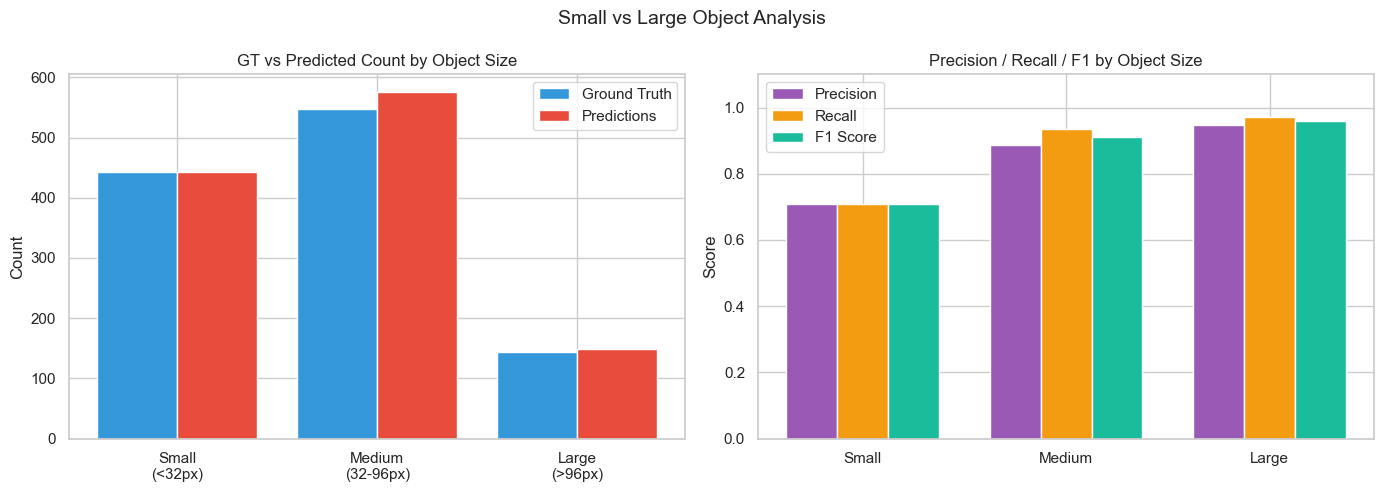

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


x = np.arange(3)
sizes = ['small', 'medium', 'large']
gt_counts   = [results_per_size[s]['GT Count']   for s in sizes]
pred_counts = [results_per_size[s]['Pred Count'] for s in sizes]

axes[0].bar(x - 0.2, gt_counts,   0.4, label='Ground Truth', color='#3498db')
axes[0].bar(x + 0.2, pred_counts, 0.4, label='Predictions',  color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Small\n(<32px)', 'Medium\n(32-96px)', 'Large\n(>96px)'])
axes[0].set_title('GT vs Predicted Count by Object Size')
axes[0].set_ylabel('Count')
axes[0].legend()


metrics_vals = {
    'Precision': [results_per_size[s]['Precision'] for s in sizes],
    'Recall'   : [results_per_size[s]['Recall']    for s in sizes],
    'F1 Score' : [results_per_size[s]['F1 Score']  for s in sizes]
}

x = np.arange(3)
width = 0.25
palette = ['#9b59b6', '#f39c12', '#1abc9c']

for i, (m, vals) in enumerate(metrics_vals.items()):
    axes[1].bar(x + (i-1)*width, vals, width, label=m, color=palette[i])

axes[1].set_xticks(x)
axes[1].set_xticklabels(['Small', 'Medium', 'Large'])
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Precision / Recall / F1 by Object Size')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.suptitle('Small vs Large Object Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('size_analysis.png')
plt.show()

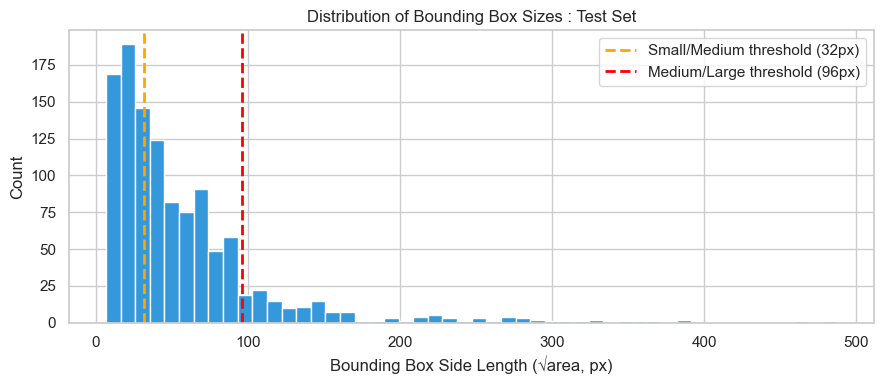

In [18]:

gt_df['area_px'] = gt_df['bw'] * gt_df['bh'] * 640 * 640

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.sqrt(gt_df['area_px']), bins=50, color='#3498db', edgecolor='white')
ax.axvline(32,  color='orange', linestyle='--', linewidth=2, label='Small/Medium threshold (32px)')
ax.axvline(96,  color='red',    linestyle='--', linewidth=2, label='Medium/Large threshold (96px)')
ax.set_xlabel('Bounding Box Side Length (√area, px)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Bounding Box Sizes : Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('bbox_size_distribution.png')
plt.show()

##Qualitative Results

Visualize prediction on sample test images.

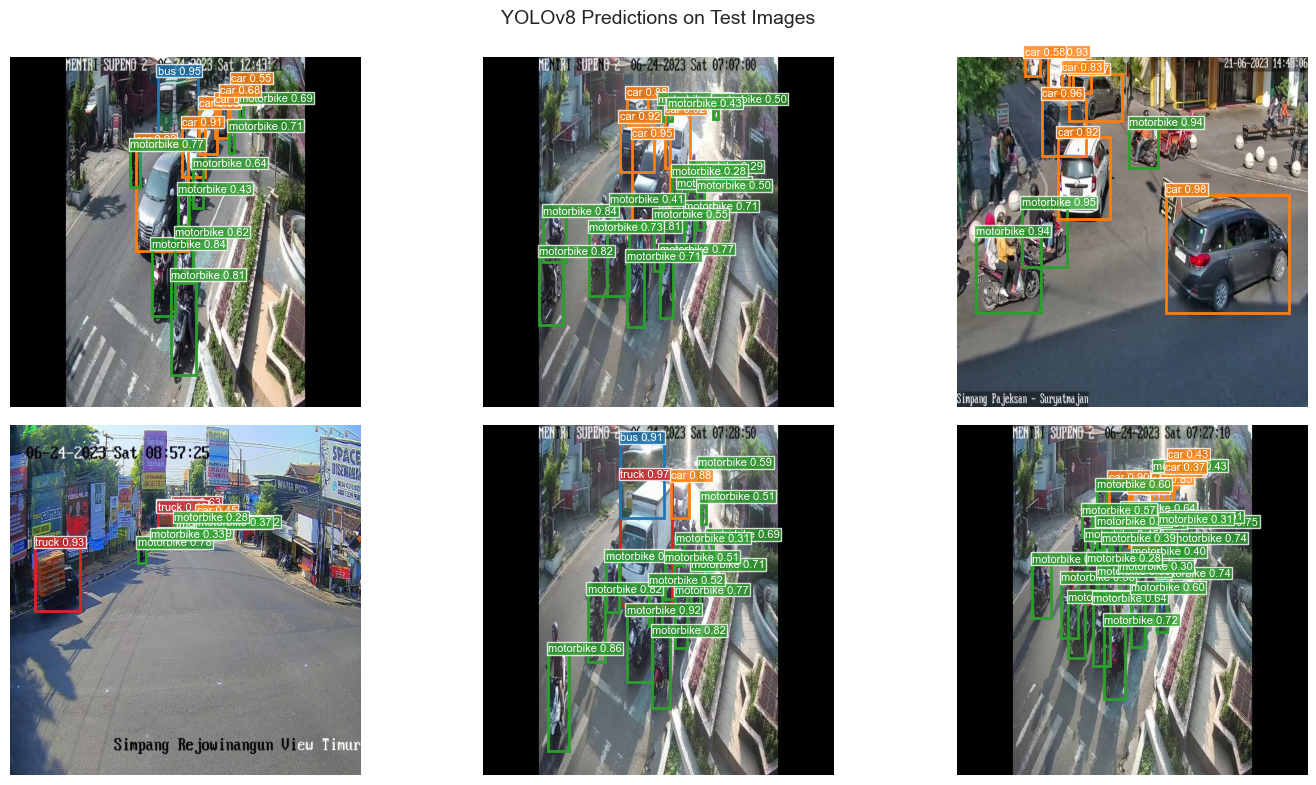

In [19]:
test_imgs = list((dataset_path / 'test' / 'images').glob('*.jpg')) + \
               list((dataset_path / 'test' / 'images').glob('*.png'))

n_samples   = min(6, len(test_imgs))
sample_imgs = np.random.choice(test_imgs, n_samples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = plt.colormaps.get_cmap('tab10')

for ax, img_path in zip(axes.flatten(), list(sample_imgs) + [None]*(6-n_samples)):
    if img_path is None:
        ax.axis('off')
        continue
    result = best_model.predict(str(img_path), conf=0.25, verbose=False)[0]
    img    = Image.open(img_path).convert('RGB')
    W, H   = img.size
    ax.imshow(img)

    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls_id  = int(box.cls[0])
            conf    = float(box.conf[0])
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor=colors(cls_id), facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-4, f'{class_names[cls_id]} {conf:.2f}',
                    color='white', fontsize=8,
                    bbox=dict(facecolor=colors(cls_id), alpha=0.8, pad=1))

    ax.axis('off')

plt.suptitle('YOLOv8 Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.savefig('qualitative_results.png')
plt.show()

## Evaluation

In [20]:
metrics = best_model.val(
    data   = data_yaml,
    split  = 'test',
    imgsz  = IMG_SIZE,
    conf   = 0.001,
    iou    = 0.6,
    verbose= True
)

print('\n Final Metrics (Test Set):')
print(f'  mAP@50     : {metrics.box.map50:.4f}')
print(f'  mAP@50-95  : {metrics.box.map:.4f}')
print(f'  Precision  : {metrics.box.mp:.4f}')
print(f'  Recall     : {metrics.box.mr:.4f}')


Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1673.9±403.3 MB/s, size: 77.3 KB)
val: Scanning /content/Vehicle-Detection-1/test/labels... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.9Kit/s 0.1s
val: New cache created: /content/Vehicle-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2it/s 5.6s
                   all        100       1133      0.884      0.884      0.928       0.74
                   bus         40         43      0.908      0.914      0.962      0.886
                   car         92        369      0.907      0.935       0.97      0.817
             motorbike         95        628      0.863      0.795      0.867      0.519
                 truck         58         93      0.856      0.892      0.914      0.737
Speed: 6.9ms preprocess, 9.1ms inference, 0.0ms loss, 8.

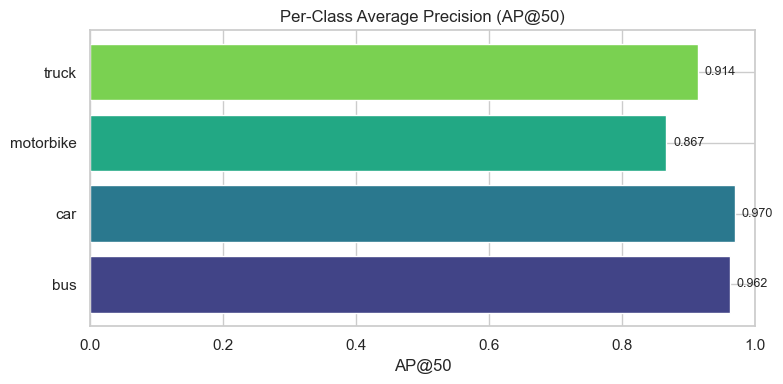

In [21]:
ap_per_class = metrics.box.ap50

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(class_names[:len(ap_per_class)], ap_per_class,
        color=sns.color_palette('viridis', len(ap_per_class)))

ax.set_xlim(0, 1)
ax.set_xlabel('AP@50')
ax.set_title('Per-Class Average Precision (AP@50)')
for i, v in enumerate(ap_per_class):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('per_class_ap.png')
plt.show()

In [22]:
import os
import shutil

os.makedirs('final_outputs', exist_ok=True)

figures = [
    'class_distribution.png',
    'augmentation_comparison.png',
    'size_analysis.png',
    'bbox_size_distribution.png',
    'qualitative_results.png',
    'per_class_ap.png'
]

for fig in figures:
    if os.path.exists(fig):
        shutil.copy(fig, f'final_outputs/{fig}')

summary.to_csv('final_outputs/augmentation_summary.csv', index=False)
size_df.to_csv('final_outputs/size_analysis.csv')

shutil.copy(best_model_path, 'final_outputs/best_model.pt')

'final_outputs/best_model.pt'